# Collaborative Filtering: From Recommendations to Embeddings

In L6, you used `nn.Embedding` to learn dense vectors for job titles and education levels. Those were lookup tables trained with gradient descent — give the layer an integer ID, get back a learned vector. The embedding was a small part of a larger model.

Now we're going to push that same idea much further. Instead of embedding categorical features *inside* an MLP, embeddings become the *entire model*. Two embedding lookups, one dot product, and you have a recommendation engine.

This lesson matters beyond recommendations. The embedding concept you'll master here is the foundation for understanding word embeddings (word2vec), sentence embeddings (what powers semantic search), and the attention mechanism in transformers (what powers every LLM). When you see `nn.Embedding(50257, 768)` as the first layer of GPT-2, you'll know exactly what it's doing — the same thing we do here, just at a larger scale.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
matplotlib.rcParams['figure.dpi'] = 100

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


## Part 1: The Recommendation Problem

Netflix spent $1 million on a competition to improve their recommendation algorithm by 10%. Spotify's Discover Weekly playlist drives 30% of all listening on the platform. Amazon estimates 35% of revenue comes from its recommendation engine.

The problem sounds simple: given what a user has liked before, predict what they'll like next. But it's fundamentally different from the classification and regression problems we've tackled so far.

### The User-Item Matrix

Imagine a giant spreadsheet. Rows are users, columns are movies, and each cell contains a rating (or is empty if the user hasn't rated that movie). This is the **user-item matrix**, and it's the core data structure for recommendation systems.

In [3]:
# A toy example: 6 users, 8 movies
toy_data = {
    'Inception': [5, None, 4, None, 5, None],
    'The Notebook': [None, 5, None, 4, None, 5],
    'Avengers': [4, None, 5, None, 4, None],
    'Titanic': [None, 4, None, 5, 1, 4],
    'The Matrix': [5, None, 4, None, None, None],
    'Mean Girls': [None, 3, None, 4, None, 3],
    'Interstellar': [4, None, None, None, 5, None],
    'Pride & Prejudice': [None, 5, None, 3, None, 4],
}
users = ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank']
toy_df = pd.DataFrame(toy_data, index=users)
toy_df.style.format('{:.0f}', na_rep='?').background_gradient(cmap='YlOrRd', vmin=1, vmax=5)

,Inception,The Notebook,Avengers,Titanic,The Matrix,Mean Girls,Interstellar,Pride & Prejudice
Alice,5,?,4,?,5,?,4,?
Bob,?,5,?,4,?,3,?,5
Carol,4,?,5,?,4,?,?,?
Dave,?,4,?,5,?,4,?,3
Eve,5,?,4,1,?,?,5,?
Frank,?,5,?,4,?,3,?,4


The `?` cells are what we want to predict. Alice rated Inception (5) and Avengers (4) but hasn't rated The Notebook — would she like it? Looking at the pattern, Alice seems to prefer action/sci-fi while Bob and Dave prefer romance/drama. That's the kind of structure a recommendation model needs to discover.

Notice how sparse this is. Even in this tiny example, about half the cells are empty. Real datasets are far worse.

[Text(0, 0, 'Inception'),
 Text(1, 0, 'The Notebook'),
 Text(2, 0, 'Avengers'),
 Text(3, 0, 'Titanic'),
 Text(4, 0, 'The Matrix'),
 Text(5, 0, 'Mean Girls'),
 Text(6, 0, 'Interstellar'),
 Text(7, 0, 'Pride & Prejudice')]

[Text(0, 0, 'Alice'),
 Text(0, 1, 'Bob'),
 Text(0, 2, 'Carol'),
 Text(0, 3, 'Dave'),
 Text(0, 4, 'Eve'),
 Text(0, 5, 'Frank')]

Text(0.5, 1.0, 'User-Item Matrix: Blue = rated, White = unknown')

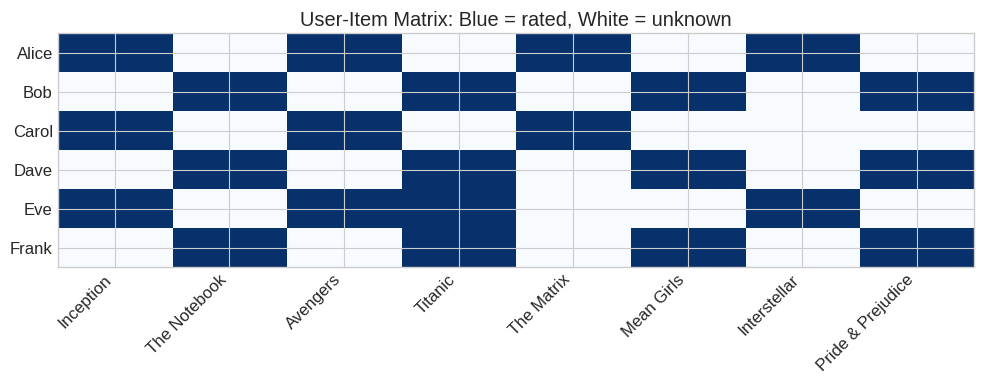

Filled: 23/48 (48%) — already 54% empty with just 6 users and 8 movies


In [4]:
# Visualize sparsity: where do we have data?
fig, ax = plt.subplots(figsize=(10, 4))
mask = toy_df.notna().astype(int)
ax.imshow(mask, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(toy_df.columns)))
ax.set_xticklabels(toy_df.columns, rotation=45, ha='right')
ax.set_yticks(range(len(toy_df.index)))
ax.set_yticklabels(toy_df.index)
ax.set_title('User-Item Matrix: Blue = rated, White = unknown')
plt.tight_layout()
plt.show()

filled = toy_df.notna().sum().sum()
total = toy_df.shape[0] * toy_df.shape[1]
print(f"Filled: {filled}/{total} ({filled/total*100:.0f}%) — already 54% empty with just 6 users and 8 movies")

### Why this is different from classification

In L4-L6, every data point had a fixed feature vector. A bank customer had age, job, education, previous contacts — concrete attributes we could feed into a model. The model learned weights for those features.

Here, there are no features. User 42 is just an ID number. Movie 1234 is just an ID number. We can't multiply them or do math with them. The model needs to **learn** a meaningful representation for each user and each movie from scratch.

That's the key shift: the model doesn't just learn weights for existing features. It learns the features themselves. Those learned features are the embeddings.

### Two approaches

**Content-based filtering:** "If you liked Inception, try Interstellar — both are sci-fi movies directed by Christopher Nolan." Uses item metadata (genre, director, description) to find similar items. Doesn't need other users' data, but requires good metadata and can't discover surprising connections.

**Collaborative filtering:** "Users who liked Inception also liked The Matrix." Uses the rating patterns across users to find structure. Doesn't need any metadata about items — just the user-item matrix. Can discover unexpected connections (users who like X tend to like Y, even if X and Y seem unrelated).

We'll focus on collaborative filtering because it's where embeddings come in, and it's more general.

### What we'll build

1. **Baselines** — how well can you predict ratings with simple averages?
2. **Matrix factorization** — learn user and movie embeddings, predict with dot product
3. **Add bias** — capture "universally good movies" and "generous raters"
4. **Neural collaborative filtering** — replace dot product with an MLP
5. **Interpret the embeddings** — what did the model learn about movies?
6. **Bridge to modern AI** — how this connects to word embeddings and transformers

## Part 2: The MovieLens Dataset

MovieLens is the standard benchmark for recommendation systems, maintained by the GroupLens research group at the University of Minnesota. Our version has 100,836 ratings from 610 users across 9,724 movies. Small enough to train on CPU in seconds, large enough to learn real patterns.

In [5]:
ratings = pd.read_csv('/data/datasets/movielens/ratings.csv')
movies = pd.read_csv('/data/datasets/movielens/movies.csv')

print(f"Ratings: {ratings.shape}")
ratings.head()

Ratings: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
print(f"Movies: {movies.shape}")
movies.head()

Movies: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
print(f"Users: {n_users}")
print(f"Movies: {n_movies}")
print(f"Ratings: {len(ratings):,}")
print(f"Average rating: {ratings['rating'].mean():.2f}")
print(f"Sparsity: {1 - len(ratings) / (n_users * n_movies):.1%}")

Users: 610
Movies: 9724
Ratings: 100,836
Average rating: 3.50
Sparsity: 98.3%


<Axes: xlabel='rating'>

Text(0.5, 1.0, 'Rating Distribution')

Text(0.5, 0, 'Rating')

Text(0, 0.5, 'Count')

(array([310.,  97.,  58.,  35.,  20.,  14.,  11.,  14.,   9.,   6.,   5.,
          4.,   2.,   4.,   0.,   3.,   2.,   4.,   1.,   2.,   1.,   0.,
          1.,   2.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   1.]),
 array([  20.  ,   73.56,  127.12,  180.68,  234.24,  287.8 ,  341.36,
         394.92,  448.48,  502.04,  555.6 ,  609.16,  662.72,  716.28,
         769.84,  823.4 ,  876.96,  930.52,  984.08, 1037.64, 1091.2 ,
        1144.76, 1198.32, 1251.88, 1305.44, 1359.  , 1412.56, 1466.12,
        1519.68, 1573.24, 1626.8 , 1680.36, 1733.92, 1787.48, 1841.04,
        1894.6 , 1948.16, 2001.72, 2055.28, 2108.84, 2162.4 , 2215.96,
        2269.52, 2323.08, 2376.64, 2430.2 , 2483.76, 2537.32, 2590.88,
        2644.44, 2698.  ]),
 <BarContainer object of 50 artists>)

Text(0.5, 1.0, 'Ratings per User (median: 70)')

Text(0.5, 0, 'Number of ratings')

(array([7.053e+03, 1.021e+03, 4.150e+02, 3.020e+02, 1.550e+02, 1.620e+02,
        1.250e+02, 8.800e+01, 7.500e+01, 4.900e+01, 3.900e+01, 3.000e+01,
        2.800e+01, 2.600e+01, 1.800e+01, 2.000e+01, 1.900e+01, 9.000e+00,
        1.300e+01, 1.100e+01, 7.000e+00, 1.200e+01, 4.000e+00, 1.000e+00,
        4.000e+00, 5.000e+00, 3.000e+00, 3.000e+00, 5.000e+00, 2.000e+00,
        7.000e+00, 0.000e+00, 2.000e+00, 3.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00]),
 array([  1.  ,   7.56,  14.12,  20.68,  27.24,  33.8 ,  40.36,  46.92,
         53.48,  60.04,  66.6 ,  73.16,  79.72,  86.28,  92.84,  99.4 ,
        105.96, 112.52, 119.08, 125.64, 132.2 , 138.76, 145.32, 151.88,
        158.44, 165.  , 171.56, 178.12, 184.68, 191.24, 197.8 , 204.36,
        210.92, 217.48, 224.04, 230.6 , 237.16, 243.72, 250.28, 256.84,
        263.4 , 

Text(0.5, 1.0, 'Ratings per Movie (median: 3)')

Text(0.5, 0, 'Number of ratings')

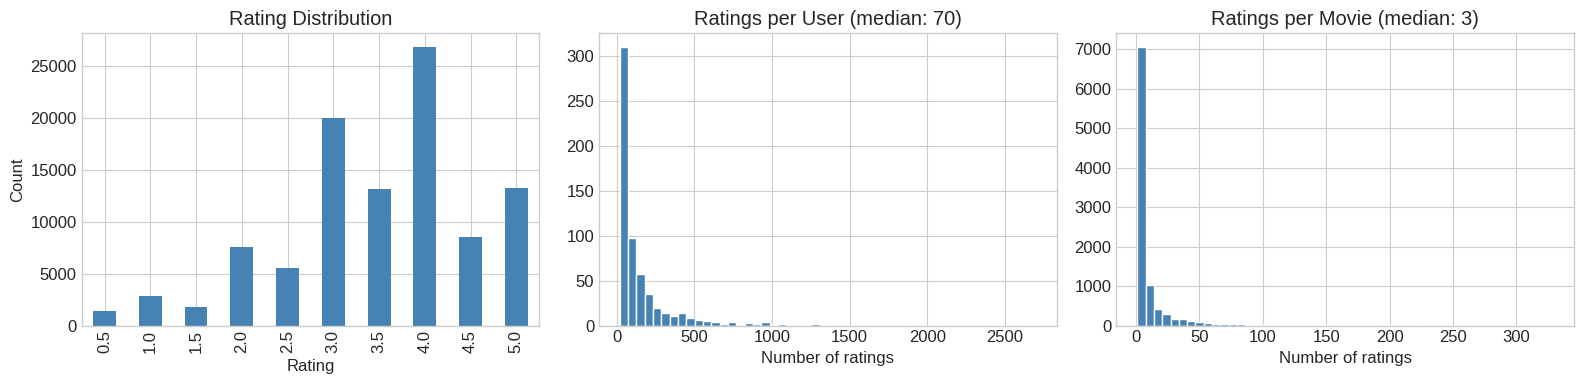

In [8]:
# Rating distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rating values
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user
ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'Ratings per User (median: {ratings_per_user.median():.0f})')
axes[1].set_xlabel('Number of ratings')

# Ratings per movie
ratings_per_movie = ratings.groupby('movieId').size()
axes[2].hist(ratings_per_movie, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title(f'Ratings per Movie (median: {ratings_per_movie.median():.0f})')
axes[2].set_xlabel('Number of ratings')

plt.tight_layout()
plt.show()

Most ratings are 3.0-4.0 (people tend to rate things they liked). Ratings per user is skewed: some users rated 20 movies, a few rated 2000+. Ratings per movie follows a power law: a few blockbusters have hundreds of ratings, most movies have very few. This is typical of real-world recommendation data.

Text(0.5, 1.0, 'User-Item Matrix (50 most active users × 80 most rated movies)')

Text(0.5, 0, 'Movies')

Text(0, 0.5, 'Users')

[]

[]

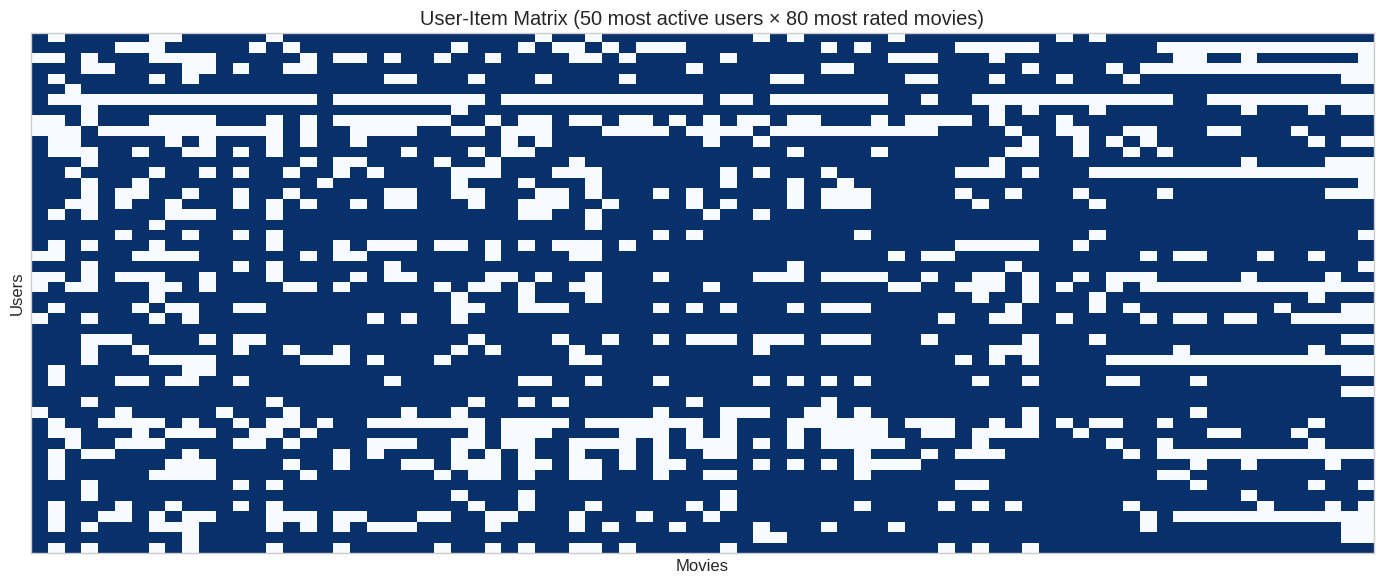

Even among the most active users and most popular movies: 74.3% filled


In [9]:
# Visualize a slice of the user-item matrix
# Take 50 most active users and 80 most rated movies
top_users = ratings_per_user.nlargest(50).index
top_movies = ratings_per_movie.nlargest(80).index

subset = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_movies)]
matrix = subset.pivot(index='userId', columns='movieId', values='rating')

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(matrix.notna().astype(int), cmap='Blues', aspect='auto', interpolation='nearest')
ax.set_title('User-Item Matrix (50 most active users × 80 most rated movies)')
ax.set_xlabel('Movies')
ax.set_ylabel('Users')
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"Even among the most active users and most popular movies: {matrix.notna().sum().sum() / matrix.size:.1%} filled")

### Baselines

Before building any model, let's establish how well simple approaches work. This gives us a floor to beat.

In [10]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(ratings, test_size=0.2, random_state=42)
print(f"Train: {len(train_df):,} ratings")
print(f"Val:   {len(val_df):,} ratings")

Train: 80,668 ratings
Val:   20,168 ratings


In [11]:
def rmse(predictions, actual):
    return np.sqrt(np.mean((predictions - actual) ** 2))

# Baseline 1: predict the global mean for everything
global_mean = train_df['rating'].mean()
rmse_global = rmse(global_mean, val_df['rating'].values)
print(f"Global mean ({global_mean:.2f}): RMSE = {rmse_global:.4f}")

# Baseline 2: predict each movie's average rating
movie_means = train_df.groupby('movieId')['rating'].mean()
preds_movie = val_df['movieId'].map(movie_means).fillna(global_mean)
rmse_movie = rmse(preds_movie.values, val_df['rating'].values)
print(f"Per-movie mean: RMSE = {rmse_movie:.4f}")

# Baseline 3: user_mean + movie_mean - global_mean
user_means = train_df.groupby('userId')['rating'].mean()
preds_combined = (
    val_df['userId'].map(user_means).fillna(global_mean) +
    val_df['movieId'].map(movie_means).fillna(global_mean) -
    global_mean
)
rmse_combined = rmse(preds_combined.values, val_df['rating'].values)
print(f"User + movie mean: RMSE = {rmse_combined:.4f}")

Global mean (3.50): RMSE = 1.0488
Per-movie mean: RMSE = 0.9827
User + movie mean: RMSE = 0.9174


The global mean is off by about 1 star on average. Per-movie means help (some movies are just better). Adding per-user means helps more (some users rate higher). But we're still just using averages — there's no learning happening. Can we do better?

## Part 3: Embeddings — The Key Idea

You already know what embeddings are from L6. When you wrote `nn.Embedding(12, 6)` for job categories, you created a lookup table: give it integer 3 ("entrepreneur"), get back a vector of 6 learned numbers. Those 6 numbers started random and got adjusted through backpropagation, just like any weight.

Now we're going to use the same mechanism, but as the *entire model* rather than just an input layer.

### The problem with IDs

User 42 and Movie 1234 are just numbers. We can't multiply them meaningfully. We need to turn each ID into a vector that captures something about the user's taste or the movie's characteristics.

One option: one-hot encoding. User 42 becomes a 610-dimensional vector with a single 1 at position 42. But that's wasteful, and it doesn't encode any similarity between users.

In [12]:
# One-hot for 610 users: a 610-dim vector with a single 1
one_hot = F.one_hot(torch.tensor(42), num_classes=610)
print(f"Shape: {one_hot.shape}")
print(f"Sum: {one_hot.sum()} (exactly one 1)")
print(f"Non-zeros: {one_hot.nonzero().squeeze().item()} (position 42)")
print(f"\nFor 9724 movies, each movie ID becomes a 9724-dim vector. That's huge and sparse.")

Shape: torch.Size([610])
Sum: 1 (exactly one 1)
Non-zeros: 42 (position 42)

For 9724 movies, each movie ID becomes a 9724-dim vector. That's huge and sparse.


### From one-hot to embedding

Here's the key insight: multiplying a one-hot vector by a weight matrix is *identical* to looking up a row in that matrix. `nn.Embedding` is just a shortcut for this lookup — no actual matrix multiplication happens.

In [13]:
# Demonstrate the equivalence
emb = nn.Embedding(5, 3)  # 5 items, 3-dim vectors
print("Embedding table (5 items × 3 dimensions):")
print(emb.weight.data.numpy().round(3))

# Method 1: embedding lookup
idx = torch.tensor([2])
result_lookup = emb(idx)
print(f"\nLookup item 2: {result_lookup.data.numpy().round(3)}")

# Method 2: one-hot × weight matrix (same result!)
one_hot = F.one_hot(torch.tensor(2), num_classes=5).float()
result_matmul = one_hot @ emb.weight
print(f"One-hot × W:   {result_matmul.data.numpy().round(3)}")

print(f"\nSame result? {torch.allclose(result_lookup, result_matmul)}")

Embedding table (5 items × 3 dimensions):
[[ 2.752  0.637 -0.411]
 [ 0.444 -0.353  0.892]
 [ 0.725 -1.009 -0.306]
 [-0.253 -1.333  0.007]
 [ 0.526  0.693  1.202]]

Lookup item 2: [[ 0.725 -1.009 -0.306]]
One-hot × W:   [ 0.725 -1.009 -0.306]

Same result? True


### The plan

Create two embedding matrices:
- **User embeddings**: 610 users × d dimensions (one vector per user)
- **Movie embeddings**: 9,724 movies × d dimensions (one vector per movie)

The **dot product** of a user vector and a movie vector = predicted rating.

Each dimension might correspond to something like "likes action movies" or "prefers long, slow-burn films" — but we never tell the model what the dimensions mean. It figures that out from the rating data alone. That's what makes it powerful.

In L6, your job category embeddings were 6-dimensional and fed into an MLP that made the final prediction. Here, the embeddings directly produce the prediction via dot product. No MLP needed (yet — we'll add one in Part 6).

Every language model starts exactly this way. GPT-2 has `nn.Embedding(50257, 768)` — 50,257 vocabulary tokens, each mapped to a 768-dimensional vector. Llama 3 has `nn.Embedding(128000, 4096)`. The first operation in any transformer is an embedding lookup. The only difference from our movie embeddings: after the lookup, transformers process the vectors through attention layers (which are themselves dot products between embeddings — we'll come back to this in Part 6).

In [14]:
# How many parameters for different embedding dimensions?
for d in [8, 16, 32, 50, 100]:
    params = n_users * d + n_movies * d
    print(f"d={d:3d}: {params:>10,} parameters ({params/len(train_df):.1f}x the number of ratings)")

print(f"\nFor comparison:")
print(f"GPT-2:   50,257 × 768  = {50257*768:>12,} embedding parameters")
print(f"Llama 3: 128,000 × 4,096 = {128000*4096:>12,} embedding parameters")

d=  8:     82,672 parameters (1.0x the number of ratings)
d= 16:    165,344 parameters (2.0x the number of ratings)
d= 32:    330,688 parameters (4.1x the number of ratings)
d= 50:    516,700 parameters (6.4x the number of ratings)
d=100:  1,033,400 parameters (12.8x the number of ratings)

For comparison:
GPT-2:   50,257 × 768  =   38,597,376 embedding parameters
Llama 3: 128,000 × 4,096 =  524,288,000 embedding parameters


We'll use d=32. That gives us ~330K parameters for 80K training ratings — enough capacity to learn useful patterns without memorizing.

## Part 4: Matrix Factorization — Build It

Time to build the simplest possible recommendation model. Two embedding tables, one dot product.

In [15]:
# Remap user and movie IDs to contiguous 0-indexed integers
# movieId in MovieLens goes up to 193609 with huge gaps — nn.Embedding needs contiguous IDs
user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user_to_idx = {uid: idx for idx, uid in enumerate(sorted(user_ids))}
movie_to_idx = {mid: idx for idx, mid in enumerate(sorted(movie_ids))}
idx_to_movie = {idx: mid for mid, idx in movie_to_idx.items()}

# Add index columns
ratings['user_idx'] = ratings['userId'].map(user_to_idx)
ratings['movie_idx'] = ratings['movieId'].map(movie_to_idx)

n_users_idx = len(user_to_idx)
n_movies_idx = len(movie_to_idx)
print(f"Users: {n_users_idx}, Movies: {n_movies_idx}")

# Re-split with the new columns
train_df, val_df = train_test_split(ratings, test_size=0.2, random_state=42)
print(f"Train: {len(train_df):,}, Val: {len(val_df):,}")

Users: 610, Movies: 9724
Train: 80,668, Val: 20,168


In [16]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.movies = torch.tensor(df['movie_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)
    
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

train_dataset = RatingsDataset(train_df)
val_dataset = RatingsDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

# Quick check
users_batch, movies_batch, ratings_batch = next(iter(train_loader))
print(f"Batch shapes: users={users_batch.shape}, movies={movies_batch.shape}, ratings={ratings_batch.shape}")

Batch shapes: users=torch.Size([1024]), movies=torch.Size([1024]), ratings=torch.Size([1024])


In [17]:
class DotProduct(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        # Initialize with small random values
        nn.init.normal_(self.user_emb.weight, 0, 0.01)
        nn.init.normal_(self.movie_emb.weight, 0, 0.01)
    
    def forward(self, users, movies):
        u = self.user_emb(users)   # (batch, emb_dim)
        m = self.movie_emb(movies) # (batch, emb_dim)
        return (u * m).sum(dim=1)  # dot product per pair

model = DotProduct(n_users_idx, n_movies_idx, emb_dim=32).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Parameters: 330,688
DotProduct(
  (user_emb): Embedding(610, 32)
  (movie_emb): Embedding(9724, 32)
)


The forward pass is literally: look up user vector, look up movie vector, element-wise multiply, sum. That's it. No hidden layers, no activation functions. Just `(user_emb * movie_emb).sum(dim=1)`.

In [18]:
def train_and_evaluate(model, train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=0, verbose=True):
    """Train a model and return training history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    
    history = {'train_loss': [], 'val_loss': [], 'val_rmse': []}
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss_total = 0
        for users, movies, ratings_batch in train_loader:
            users, movies, ratings_batch = users.to(device), movies.to(device), ratings_batch.to(device)
            preds = model(users, movies)
            loss = loss_fn(preds, ratings_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item()
        
        # Validate
        model.eval()
        val_loss_total = 0
        all_preds, all_actual = [], []
        with torch.no_grad():
            for users, movies, ratings_batch in val_loader:
                users, movies, ratings_batch = users.to(device), movies.to(device), ratings_batch.to(device)
                preds = model(users, movies)
                val_loss_total += loss_fn(preds, ratings_batch).item()
                all_preds.append(preds.cpu())
                all_actual.append(ratings_batch.cpu())
        
        avg_train = train_loss_total / len(train_loader)
        avg_val = val_loss_total / len(val_loader)
        val_rmse = torch.sqrt(torch.mean((torch.cat(all_preds) - torch.cat(all_actual)) ** 2)).item()
        
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_rmse'].append(val_rmse)
        
        if verbose and (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d}: train_loss={avg_train:.4f}, val_loss={avg_val:.4f}, val_rmse={val_rmse:.4f}")
    
    return history

In [19]:
model_v1 = DotProduct(n_users_idx, n_movies_idx, emb_dim=32).to(device)
history_v1 = train_and_evaluate(model_v1, train_loader, val_loader, epochs=20, lr=1e-3)

Epoch  5: train_loss=2.9303, val_loss=2.6776, val_rmse=1.6360


Epoch 10: train_loss=1.0851, val_loss=1.5055, val_rmse=1.2265


Epoch 15: train_loss=0.7888, val_loss=1.3106, val_rmse=1.1443


Epoch 20: train_loss=0.6807, val_loss=1.2527, val_rmse=1.1187


Text(0.5, 1.0, 'Loss')

Text(0.5, 0, 'Epoch')

Text(0.5, 1.0, 'Validation RMSE vs Baselines')

Text(0.5, 0, 'Epoch')

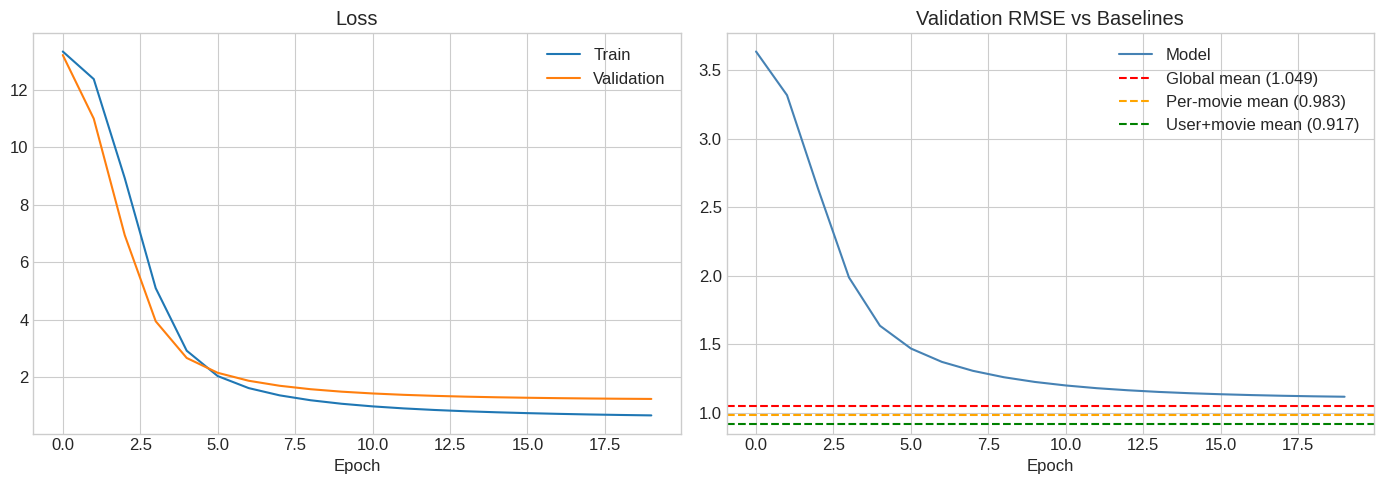


Final RMSE: 1.1187 (vs global mean: 1.0488)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_v1['train_loss'], label='Train')
axes[0].plot(history_v1['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_v1['val_rmse'], label='Model', color='steelblue')
axes[1].axhline(y=rmse_global, color='red', linestyle='--', label=f'Global mean ({rmse_global:.3f})')
axes[1].axhline(y=rmse_movie, color='orange', linestyle='--', label=f'Per-movie mean ({rmse_movie:.3f})')
axes[1].axhline(y=rmse_combined, color='green', linestyle='--', label=f'User+movie mean ({rmse_combined:.3f})')
axes[1].set_title('Validation RMSE vs Baselines')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFinal RMSE: {history_v1['val_rmse'][-1]:.4f} (vs global mean: {rmse_global:.4f})")

The model learns — training loss decreases — but the validation RMSE is actually *worse* than our simple baselines. What went wrong?

The dot product can produce any value: negative numbers, values above 5. Predicting 7.3 when the max rating is 5.0 incurs huge squared error. The model wastes capacity on an unconstrained output range. Let's fix that.

In [21]:
# Check prediction range
model_v1.eval()
with torch.no_grad():
    all_preds = []
    for u_batch, m_batch, _ in val_loader:
        preds = model_v1(u_batch.to(device), m_batch.to(device))
        all_preds.append(preds.cpu())
    all_preds = torch.cat(all_preds)

print(f"Prediction range: [{all_preds.min():.2f}, {all_preds.max():.2f}]")
print(f"Valid rating range: [0.5, 5.0]")
print(f"Predictions below 0.5: {(all_preds < 0.5).sum().item()}")
print(f"Predictions above 5.0: {(all_preds > 5.0).sum().item()}")

DotProduct(
  (user_emb): Embedding(610, 32)
  (movie_emb): Embedding(9724, 32)
)

Prediction range: [-0.10, 5.49]
Valid rating range: [0.5, 5.0]
Predictions below 0.5: 821
Predictions above 5.0: 68


In [22]:
# Fix: add sigmoid_range to constrain predictions
class DotProductClamped(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim, y_range=(0.5, 5.5)):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.y_range = y_range
        nn.init.normal_(self.user_emb.weight, 0, 0.01)
        nn.init.normal_(self.movie_emb.weight, 0, 0.01)
    
    def forward(self, users, movies):
        u = self.user_emb(users)
        m = self.movie_emb(movies)
        dot = (u * m).sum(dim=1)
        # sigmoid squishes to (0,1), then we scale to our range
        return torch.sigmoid(dot) * (self.y_range[1] - self.y_range[0]) + self.y_range[0]

model_v1b = DotProductClamped(n_users_idx, n_movies_idx, emb_dim=32).to(device)
history_v1b = train_and_evaluate(model_v1b, train_loader, val_loader, epochs=20, lr=1e-3)

print(f"\nUnclamped RMSE: {min(history_v1['val_rmse']):.4f}")
print(f"Clamped RMSE:   {min(history_v1b['val_rmse']):.4f}")

Epoch  5: train_loss=0.7304, val_loss=0.8305, val_rmse=0.9118


Epoch 10: train_loss=0.5279, val_loss=0.7766, val_rmse=0.8817


Epoch 15: train_loss=0.4120, val_loss=0.7726, val_rmse=0.8794


Epoch 20: train_loss=0.3254, val_loss=0.7835, val_rmse=0.8856

Unclamped RMSE: 1.1187
Clamped RMSE:   0.8788


## Part 5: Adding Bias

Some movies are just universally good. The Shawshank Redemption has a higher average rating regardless of who watches it. Similarly, some users rate everything high (generous raters) and others rate everything low (harsh critics).

The dot product captures *interactions* between user taste and movie characteristics, but it doesn't capture these global tendencies. We fix that by adding a scalar bias per user and per movie:

```
prediction = dot(user_emb, movie_emb) + user_bias + movie_bias + global_bias
```

In [23]:
class BiasedDotProduct(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim, y_range=(0.5, 5.5)):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        self.y_range = y_range
        
        nn.init.normal_(self.user_emb.weight, 0, 0.01)
        nn.init.normal_(self.movie_emb.weight, 0, 0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
    
    def forward(self, users, movies):
        u = self.user_emb(users)
        m = self.movie_emb(movies)
        dot = (u * m).sum(dim=1)
        bias = self.user_bias(users).squeeze() + self.movie_bias(movies).squeeze() + self.global_bias
        return torch.sigmoid(dot + bias) * (self.y_range[1] - self.y_range[0]) + self.y_range[0]

In [24]:
model_v2 = BiasedDotProduct(n_users_idx, n_movies_idx, emb_dim=32).to(device)
history_v2 = train_and_evaluate(model_v2, train_loader, val_loader, epochs=30, lr=1e-3, weight_decay=1e-5)

Epoch  5: train_loss=0.6675, val_loss=0.7702, val_rmse=0.8782


Epoch 10: train_loss=0.4747, val_loss=0.7339, val_rmse=0.8572


Epoch 15: train_loss=0.3555, val_loss=0.7386, val_rmse=0.8600


Epoch 20: train_loss=0.2701, val_loss=0.7556, val_rmse=0.8699


Epoch 25: train_loss=0.2091, val_loss=0.7780, val_rmse=0.8827


Epoch 30: train_loss=0.1666, val_loss=0.8028, val_rmse=0.8966


Text(0.5, 0, 'RMSE (lower is better)')

Text(0.5, 1.0, 'Model Comparison')

Text(1.0538405992661315, 0.0, '1.0488')

Text(0.9877389937822489, 1.0, '0.9827')

Text(0.9224463561734154, 2.0, '0.9174')

Text(1.1236832189559935, 3.0, '1.1187')

Text(0.883843367099762, 4.0, '0.8788')

Text(0.8621314811706543, 5.0, '0.8571')

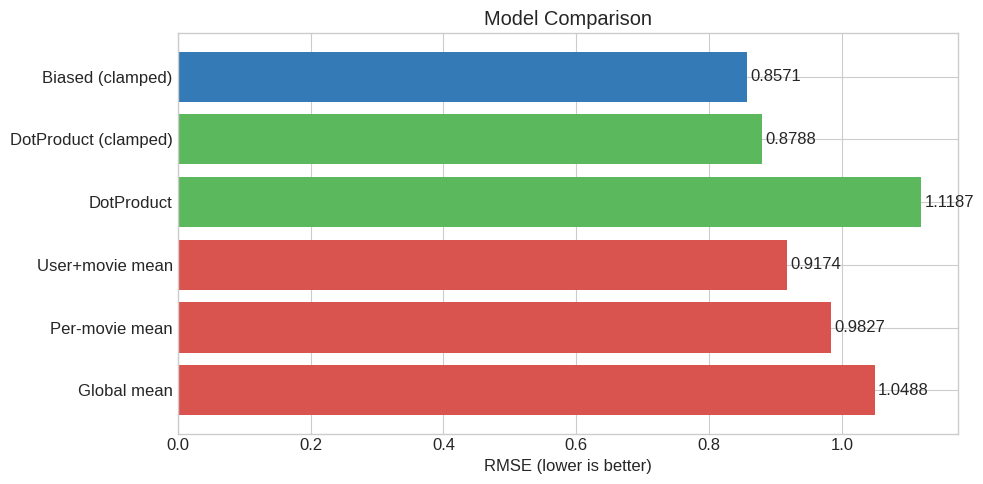

In [25]:
# Compare all models so far
results = {
    'Global mean': rmse_global,
    'Per-movie mean': rmse_movie,
    'User+movie mean': rmse_combined,
    'DotProduct': min(history_v1['val_rmse']),
    'DotProduct (clamped)': min(history_v1b['val_rmse']),
    'Biased (clamped)': min(history_v2['val_rmse']),
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f', '#d9534f', '#d9534f', '#5cb85c', '#5cb85c', '#337ab7']
bars = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('Model Comparison')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()

### Inspecting the biases

The bias values are directly interpretable. A movie with a high positive bias is universally liked regardless of user taste. A user with a negative bias is a harsh critic.

In [26]:
# Extract movie biases and merge with titles
movie_biases = model_v2.movie_bias.weight.data.cpu().squeeze().numpy()
bias_df = pd.DataFrame({
    'movie_idx': range(len(movie_biases)),
    'bias': movie_biases
})
bias_df['movieId'] = bias_df['movie_idx'].map(idx_to_movie)
bias_df = bias_df.merge(movies[['movieId', 'title']], on='movieId')

# Only consider movies with enough ratings for reliable bias
movie_rating_counts = ratings.groupby('movieId').size().reset_index(name='count')
bias_df = bias_df.merge(movie_rating_counts, on='movieId')
popular = bias_df[bias_df['count'] >= 50].sort_values('bias', ascending=False)

print("Top 10 movies (highest bias — universally liked):")
for _, row in popular.head(10).iterrows():
    print(f"  {row['bias']:+.3f}  {row['title']} ({row['count']} ratings)")

print(f"\nBottom 10 movies (lowest bias — universally disliked):")
for _, row in popular.tail(10).iterrows():
    print(f"  {row['bias']:+.3f}  {row['title']} ({row['count']} ratings)")

Top 10 movies (highest bias — universally liked):
  +0.413  Shawshank Redemption, The (1994) (317 ratings)
  +0.369  Forrest Gump (1994) (329 ratings)
  +0.314  Up (2009) (105 ratings)
  +0.306  Green Mile, The (1999) (111 ratings)
  +0.286  Casablanca (1942) (100 ratings)
  +0.282  King's Speech, The (2010) (58 ratings)
  +0.281  Harry Potter and the Prisoner of Azkaban (2004) (93 ratings)
  +0.277  Harry Potter and the Goblet of Fire (2005) (71 ratings)
  +0.256  Good Will Hunting (1997) (141 ratings)
  +0.253  Dark Knight, The (2008) (149 ratings)

Bottom 10 movies (lowest bias — universally disliked):
  -0.190  Dumb & Dumber (Dumb and Dumber) (1994) (133 ratings)
  -0.202  Borat: Cultural Learnings of America for Make Benefit Glorious Nation of Kazakhstan (2006) (65 ratings)
  -0.208  Cliffhanger (1993) (101 ratings)
  -0.218  Blair Witch Project, The (1999) (64 ratings)
  -0.218  Cable Guy, The (1996) (54 ratings)
  -0.221  Charlie and the Chocolate Factory (2005) (61 ratings)
  -

(array([ 1.,  3.,  1.,  2.,  2.,  4.,  1.,  3.,  3.,  4.,  0.,  7., 11.,
        15., 14., 12., 19., 13., 21., 20., 23., 22., 22., 28., 31., 25.,
        26., 31., 29., 26., 26., 17., 25., 31., 19., 16., 13., 13.,  7.,
         4.,  4.,  4.,  1.,  2.,  2.,  2.,  1.,  1.,  1.,  2.]),
 array([-0.47507069, -0.45341763, -0.43176454, -0.41011149, -0.38845843,
        -0.36680534, -0.34515229, -0.3234992 , -0.30184615, -0.28019309,
        -0.25854   , -0.23688695, -0.21523389, -0.19358081, -0.17192775,
        -0.15027466, -0.12862161, -0.10696855, -0.08531547, -0.06366241,
        -0.04200932, -0.02035627,  0.00129679,  0.02294987,  0.0446029 ,
         0.06625602,  0.08790907,  0.10956213,  0.13121518,  0.15286824,
         0.17452136,  0.19617441,  0.21782747,  0.23948053,  0.26113358,
         0.2827867 ,  0.30443975,  0.32609281,  0.34774587,  0.36939892,
         0.39105204,  0.41270509,  0.43435815,  0.45601121,  0.47766426,
         0.49931732,  0.52097046,  0.5426234 ,  0.56427646,

Text(0.5, 1.0, 'User Bias Distribution')

Text(0.5, 0, 'Bias (+ = generous, - = harsh)')

Text(0, 0.5, 'Number of users')

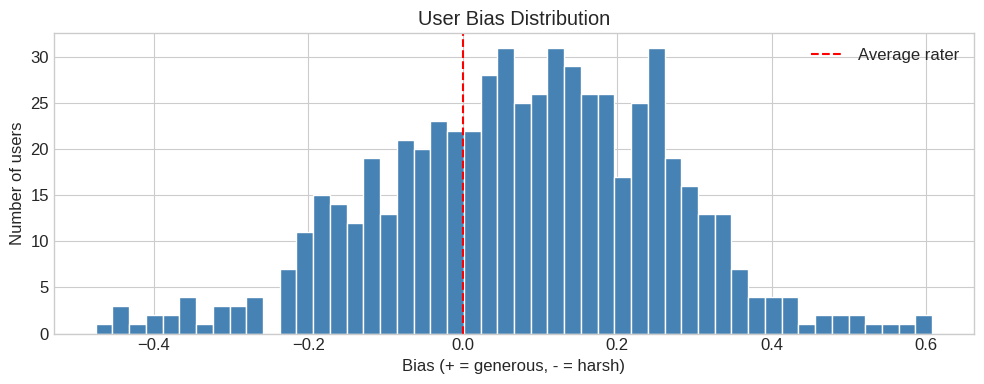

In [27]:
# User bias distribution
user_biases = model_v2.user_bias.weight.data.cpu().squeeze().numpy()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_biases, bins=50, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='Average rater')
ax.set_title('User Bias Distribution')
ax.set_xlabel('Bias (+ = generous, - = harsh)')
ax.set_ylabel('Number of users')
ax.legend()
plt.tight_layout()
plt.show()

## Part 6: Neural Collaborative Filtering

The dot product model is elegant but limited. It assumes user-movie compatibility is a *linear* function of their latent factors. What if the relationship is more complex? What if the first few dimensions interact non-linearly with the last few?

Solution: instead of computing a dot product, **concatenate** the user and movie embeddings and feed them through an MLP. The MLP can learn arbitrary non-linear interactions between the embedding dimensions.

This is structurally identical to what you built in L6. In L6, you concatenated embedded categoricals (job, education, marital status) with numerical features and passed them through linear layers. Here, you concatenate two embeddings (user + movie) and do the same thing. Same architecture, different input.

In [28]:
class NeuralCollabFilter(nn.Module):
    def __init__(self, n_users, n_movies, emb_dim, hidden=128, y_range=(0.5, 5.5)):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.movie_emb = nn.Embedding(n_movies, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.y_range = y_range
        
        # MLP that processes concatenated embeddings
        self.layers = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden // 2, 1),
        )
        
        nn.init.normal_(self.user_emb.weight, 0, 0.01)
        nn.init.normal_(self.movie_emb.weight, 0, 0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
    
    def forward(self, users, movies):
        u = self.user_emb(users)
        m = self.movie_emb(movies)
        # Concatenate instead of dot product
        x = torch.cat([u, m], dim=1)
        mlp_out = self.layers(x).squeeze()
        bias = self.user_bias(users).squeeze() + self.movie_bias(movies).squeeze()
        return torch.sigmoid(mlp_out + bias) * (self.y_range[1] - self.y_range[0]) + self.y_range[0]

In [29]:
model_v3 = NeuralCollabFilter(n_users_idx, n_movies_idx, emb_dim=32).to(device)
print(f"Parameters: {sum(p.numel() for p in model_v3.parameters()):,}")
history_v3 = train_and_evaluate(model_v3, train_loader, val_loader, epochs=25, lr=1e-3, weight_decay=1e-5)

Parameters: 357,663


Epoch  5: train_loss=0.6457, val_loss=0.7605, val_rmse=0.8728


Epoch 10: train_loss=0.5805, val_loss=0.7836, val_rmse=0.8859


Epoch 15: train_loss=0.5377, val_loss=0.7937, val_rmse=0.8916


Epoch 20: train_loss=0.4977, val_loss=0.8083, val_rmse=0.8999


Epoch 25: train_loss=0.4564, val_loss=0.8340, val_rmse=0.9142


Text(0.5, 0, 'RMSE (lower is better)')

Text(0.5, 1.0, 'Model Comparison')

Text(1.0538405992661315, 0.0, '1.0488')

Text(0.9877389937822489, 1.0, '0.9827')

Text(0.9224463561734154, 2.0, '0.9174')

Text(1.1236832189559935, 3.0, '1.1187')

Text(0.883843367099762, 4.0, '0.8788')

Text(0.8621314811706543, 5.0, '0.8571')

Text(0.8778432655334473, 6.0, '0.8728')

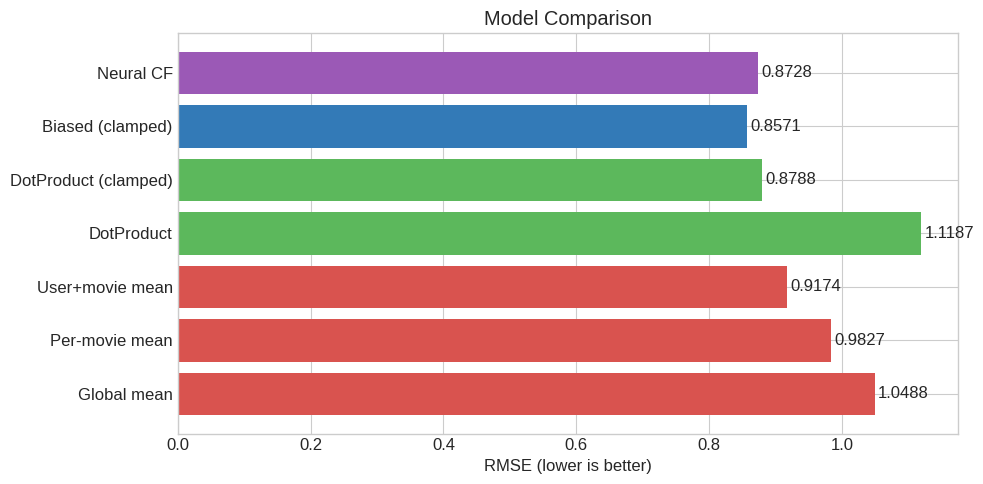

In [30]:
# Update comparison
results['Neural CF'] = min(history_v3['val_rmse'])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f', '#d9534f', '#d9534f', '#5cb85c', '#5cb85c', '#337ab7', '#9b59b6']
bars = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.set_xlabel('RMSE (lower is better)')
ax.set_title('Model Comparison')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()

On 100K ratings, the neural version is comparable to the biased dot product. On larger datasets (millions of ratings), the gap grows in favor of neural models. In practice, most production systems use neural versions or something even more complex.

**When to use which:** Dot product is simple, fast, and interpretable (you can directly analyze the embedding space). Neural is more expressive, better on large datasets, but harder to interpret because the MLP transforms the embeddings.

### The connection to attention

Look at what the dot product model does: it takes two learned vectors (user, movie) and measures their **compatibility** via dot product. High dot product = good match.

This is exactly what the **attention mechanism** in transformers does. In self-attention, every token has a **query** vector and a **key** vector (both derived from embeddings). The attention score between token A and token B is `dot(query_A, key_B)`. High score = token A should "pay attention" to token B.

Same operation, different context:

| | Collaborative Filtering | Transformer Attention |
|---|---|---|
| **Vectors** | user embedding, movie embedding | query embedding, key embedding |
| **Operation** | dot product | dot product |
| **Meaning** | "how much does this user like this movie?" | "how relevant is this token to that token?" |
| **Learned via** | backprop from rating prediction | backprop from next-token prediction |

The neural version (concatenate + MLP) corresponds to a different kind of interaction. Transformers use *both*: dot product attention to compute scores, then MLP processing of the results (the feed-forward layers after attention). You've now seen the building blocks of both.

## Part 7: What the Embeddings Learned

The model was never told about genres. It never saw the words "action" or "comedy." It only saw: user X gave movie Y a rating of Z. Yet the learned embeddings encode meaningful structure. Let's look.

In [31]:
# Use the biased model's embeddings (cleaner than neural since no MLP distortion)
movie_embeddings = model_v2.movie_emb.weight.data.cpu().numpy()
print(f"Movie embedding matrix: {movie_embeddings.shape}")

Movie embedding matrix: (9724, 32)


In [32]:
# PCA: reduce 32 dimensions to 2 for visualization
pca = PCA(n_components=2)
movie_2d = pca.fit_transform(movie_embeddings)
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

# Map movie indices to genres for coloring
movie_info = pd.DataFrame({
    'movie_idx': range(len(movie_embeddings)),
    'x': movie_2d[:, 0],
    'y': movie_2d[:, 1],
})
movie_info['movieId'] = movie_info['movie_idx'].map(idx_to_movie)
movie_info = movie_info.merge(movies, on='movieId')
movie_info = movie_info.merge(movie_rating_counts, on='movieId')

# Get primary genre
movie_info['primary_genre'] = movie_info['genres'].str.split('|').str[0]

Variance explained: 31.4%


Text(-0.45145609974861145, 0.3723973035812378, 'Toy Story (1995)')

Text(-0.8059515357017517, 0.18516254425048828, 'Star Wars: Episode IV - A New ')

Text(-1.0142067670822144, -0.1888211965560913, 'Pulp Fiction (1994)')

Text(-0.45495203137397766, 0.5391902923583984, 'Forrest Gump (1994)')

Text(-0.24487335979938507, 0.44536641240119934, 'Jurassic Park (1993)')

Text(-0.1439339816570282, 0.3019680976867676, 'Titanic (1997)')

Text(0.5, 1.0, 'Movie Embeddings (PCA to 2D) — colored by genre')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

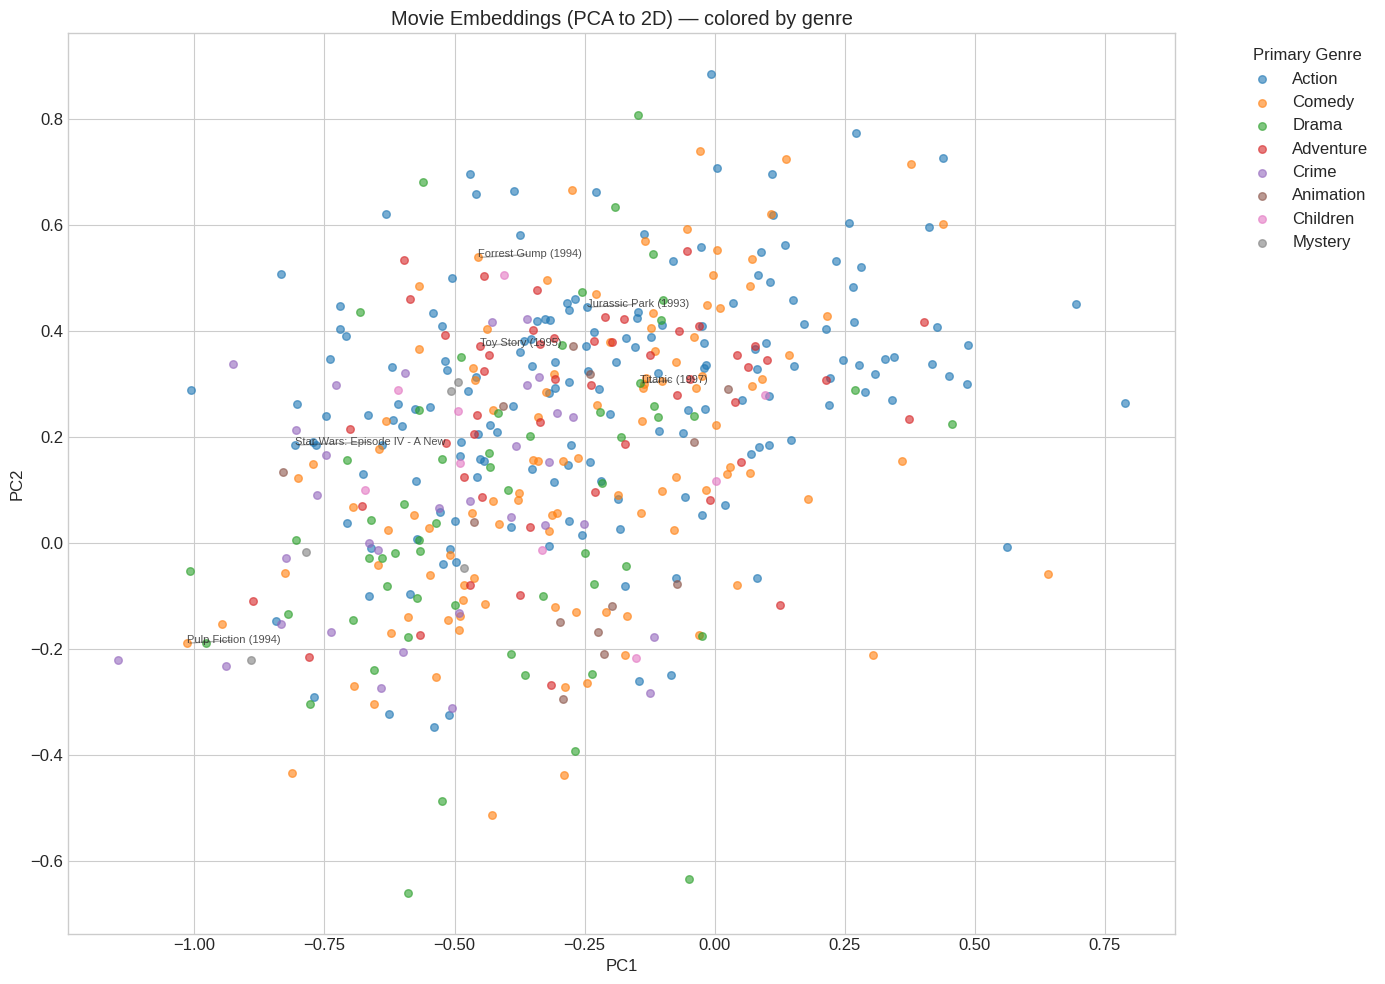

In [33]:
# Plot well-rated movies (50+ ratings) colored by genre
popular_movies = movie_info[movie_info['count'] >= 50].copy()

# Top genres for coloring
top_genres = popular_movies['primary_genre'].value_counts().head(8).index.tolist()
genre_colors = dict(zip(top_genres, plt.cm.tab10.colors[:8]))

fig, ax = plt.subplots(figsize=(14, 10))
for genre in top_genres:
    subset = popular_movies[popular_movies['primary_genre'] == genre]
    ax.scatter(subset['x'], subset['y'], label=genre, alpha=0.6, s=30, color=genre_colors[genre])

# Label some recognizable movies
labels = ['Toy Story (1995)', 'Pulp Fiction (1994)', 'The Matrix (1999)', 
          'Forrest Gump (1994)', 'Star Wars: Episode IV', 'The Silence of the Lambs (1991)',
          'Titanic (1997)', 'The Godfather (1972)', 'Jurassic Park (1993)']
for _, row in popular_movies.iterrows():
    if any(l in row['title'] for l in labels):
        ax.annotate(row['title'][:30], (row['x'], row['y']), fontsize=8, alpha=0.8,
                   arrowprops=dict(arrowstyle='-', alpha=0.3))

ax.legend(title='Primary Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Movie Embeddings (PCA to 2D) — colored by genre')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

Genre clusters emerge without the model ever being told about genres. Action movies group together. Comedies cluster together. The model discovered that users who like one action movie tend to like other action movies, so it placed them near each other in embedding space.

This is exactly the same phenomenon you'll see with word embeddings: words used in similar contexts get similar vectors. And with sentence embeddings: sentences about similar topics cluster together.

In [34]:
# Find similar movies using cosine similarity
def find_similar(title_query, n=10):
    """Find movies most similar to the given title in embedding space."""
    # Find the movie
    matches = movie_info[movie_info['title'].str.contains(title_query, case=False, na=False)]
    if len(matches) == 0:
        print(f"No movie found matching '{title_query}'")
        return
    
    target = matches.iloc[0]
    target_emb = movie_embeddings[target['movie_idx']].reshape(1, -1)
    
    # Compute cosine similarity to all movies
    sims = cosine_similarity(target_emb, movie_embeddings)[0]
    
    # Get top N (excluding self), only popular movies
    popular_idx = movie_info[movie_info['count'] >= 20]['movie_idx'].values
    sim_scores = [(idx, sims[idx]) for idx in popular_idx if idx != target['movie_idx']]
    sim_scores.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Movies similar to: {target['title']}")
    print(f"{'Title':<50} {'Similarity':>10} {'Genre'}")
    print("-" * 85)
    for idx, sim in sim_scores[:n]:
        row = movie_info[movie_info['movie_idx'] == idx].iloc[0]
        print(f"{row['title'][:48]:<50} {sim:>10.3f} {row['genres'][:25]}")

In [35]:
find_similar('Toy Story')

Movies similar to: Toy Story (1995)
Title                                              Similarity Genre
-------------------------------------------------------------------------------------
Aladdin (1992)                                          0.773 Adventure|Animation|Child
Finding Nemo (2003)                                     0.660 Adventure|Animation|Child
Wallace & Gromit: The Wrong Trousers (1993)             0.647 Animation|Children|Comedy
Tarzan (1999)                                           0.609 Adventure|Animation|Child
The Imitation Game (2014)                               0.604 Drama|Thriller|War
Rudy (1993)                                             0.602 Drama
Full Monty, The (1997)                                  0.601 Comedy|Drama
Lion King, The (1994)                                   0.599 Adventure|Animation|Child
It's a Wonderful Life (1946)                            0.595 Children|Drama|Fantasy|Ro
Ghostbusters (a.k.a. Ghost Busters) (1984)              0.

In [36]:
find_similar('Matrix')

Movies similar to: Matrix, The (1999)
Title                                              Similarity Genre
-------------------------------------------------------------------------------------
Saving Private Ryan (1998)                              0.838 Action|Drama|War
Inception (2010)                                        0.770 Action|Crime|Drama|Myster
Batman Begins (2005)                                    0.676 Action|Crime|IMAX
Aliens (1986)                                           0.670 Action|Adventure|Horror|S
Snatch (2000)                                           0.632 Comedy|Crime|Thriller
District 9 (2009)                                       0.615 Mystery|Sci-Fi|Thriller
Rise of the Planet of the Apes (2011)                   0.613 Action|Drama|Sci-Fi|Thril
Ex Machina (2015)                                       0.611 Drama|Sci-Fi|Thriller
Gravity (2013)                                          0.605 Action|Sci-Fi|IMAX
Sin City (2005)                                   

In [37]:
find_similar('Godfather')

Movies similar to: Godfather, The (1972)
Title                                              Similarity Genre
-------------------------------------------------------------------------------------
Godfather: Part II, The (1974)                          0.843 Crime|Drama
Little Big Man (1970)                                   0.759 Western
In the Name of the Father (1993)                        0.725 Drama
Boondock Saints, The (2000)                             0.702 Action|Crime|Drama|Thrill
Her (2013)                                              0.701 Drama|Romance|Sci-Fi
Reservoir Dogs (1992)                                   0.690 Crime|Mystery|Thriller
All the President's Men (1976)                          0.662 Drama|Thriller
Apocalypse Now (1979)                                   0.660 Action|Drama|War
Goodfellas (1990)                                       0.656 Crime|Drama
Doctor Zhivago (1965)                                   0.654 Drama|Romance|War


The model learned that Toy Story is similar to other animated/family films, The Matrix is similar to other sci-fi action films, and The Godfather is similar to other classic dramas — all from rating patterns alone. No metadata, no genre labels, no text descriptions. Just who rated what.

This is not hand-crafted similarity. The model learned it through gradient descent on the rating prediction task. The embeddings organized themselves so that similar items are close because that's what minimizes prediction error.

### The word2vec connection

Replace "movie" with "word" and this is exactly **word2vec**:

| Collaborative Filtering | word2vec |
|---|---|
| Movies rated by similar users → similar vectors | Words in similar contexts → similar vectors |
| "Toy Story" and "Finding Nemo" are close because similar users rated them highly | "king" and "queen" are close because they appear in similar sentences |
| Trained by predicting ratings | Trained by predicting surrounding words |
| Both: `nn.Embedding` + gradient descent | Both: `nn.Embedding` + gradient descent |

Scale this up further: modern **sentence embedding** models map entire sentences to vectors. "How do I reset my password?" and "I forgot my login credentials" end up close in embedding space because they mean similar things. Same principle: learned dense vectors that capture semantic meaning.

Everything you see here — learned dense representations, cosine similarity for retrieval, PCA for visualization — is the exact same toolkit you'll use for understanding sentence embeddings, debugging RAG systems, and inspecting transformer representations in the upcoming lessons.

Text(0.5, 1.0, 'User Embeddings (PCA to 2D)')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

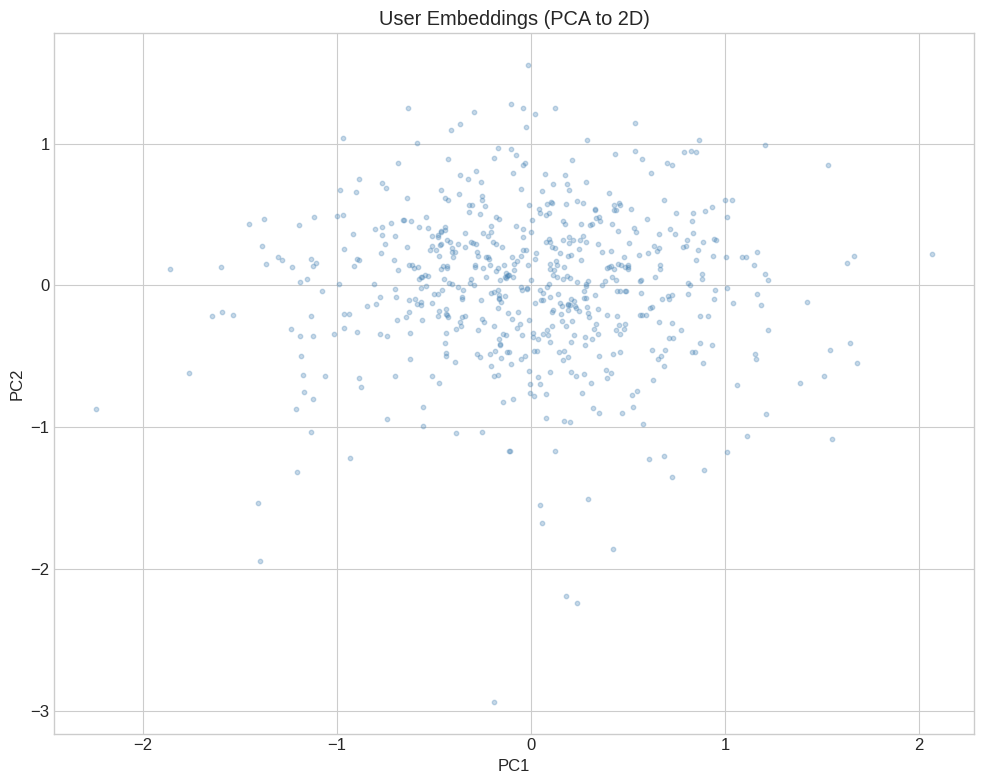

User embeddings are harder to interpret since we don't have ground truth for 'user types.'
But the spread suggests the model learned meaningful differences between users.


In [38]:
# User embeddings: do users with similar taste cluster?
user_embeddings = model_v2.user_emb.weight.data.cpu().numpy()
user_2d = PCA(n_components=2).fit_transform(user_embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(user_2d[:, 0], user_2d[:, 1], alpha=0.3, s=10, color='steelblue')
ax.set_title('User Embeddings (PCA to 2D)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

print("User embeddings are harder to interpret since we don't have ground truth for 'user types.'")
print("But the spread suggests the model learned meaningful differences between users.")

## Part 8: Beyond Explicit Ratings

MovieLens is clean and explicit: users deliberately gave 1-5 star ratings. This is the exception, not the rule. Most recommendation data in the real world is **implicit** — you observe user *behavior* rather than user *opinions*.

Examples:
- **Spotify**: Did they skip the song or listen to the end? Did they add it to a playlist?
- **Netflix**: Did they watch 5 minutes or the whole movie? Did they watch it twice?
- **Amazon**: Browsing history, add-to-cart, purchase, return
- **Steam**: How many hours did they play? Are they still playing?

No one rates every product they use. But their behavior tells us something.

In [39]:
import gzip
import ast

# Load a sample of Steam data to see the difference
steam_items = []
with gzip.open('/data/datasets/steam_games/australian_users_items.json.gz', 'rt') as f:
    for i, line in enumerate(f):
        if i >= 500:  # Just first 500 users
            break
        user = ast.literal_eval(line.strip())
        for item in user['items']:
            steam_items.append({
                'user_id': user['user_id'],
                'item_name': item['item_name'],
                'playtime_forever': item['playtime_forever'],
            })

steam_df = pd.DataFrame(steam_items)
print(f"Sample: {len(steam_df):,} interactions from 500 users")
print(f"\nPlaytime stats (minutes):")
steam_df['playtime_forever'].describe()

Sample: 43,667 interactions from 500 users

Playtime stats (minutes):


count     43667.000000
mean       1342.792864
std        7533.557275
min           0.000000
25%           0.000000
50%          42.000000
75%         397.000000
max      400827.000000
Name: playtime_forever, dtype: float64

(array([2.6287e+04, 1.0920e+03, 4.3500e+02, 2.2700e+02, 1.5000e+02,
        1.0400e+02, 8.3000e+01, 6.2000e+01, 4.3000e+01, 4.0000e+01,
        4.5000e+01, 2.7000e+01, 2.1000e+01, 2.0000e+01, 1.7000e+01,
        1.3000e+01, 1.1000e+01, 1.3000e+01, 8.0000e+00, 9.0000e+00,
        5.0000e+00, 1.0000e+01, 3.0000e+00, 6.0000e+00, 4.0000e+00,
        3.0000e+00, 1.0000e+00, 6.0000e+00, 6.0000e+00, 6.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        4.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

Text(0.5, 1.0, 'Raw Playtime (minutes) — useless')

Text(0.5, 0, 'Minutes')

(array([9.490e+02, 3.400e+02, 2.770e+02, 2.610e+02, 2.400e+02, 4.160e+02,
        5.940e+02, 5.170e+02, 5.840e+02, 5.720e+02, 8.110e+02, 8.700e+02,
        8.900e+02, 1.027e+03, 9.830e+02, 1.075e+03, 1.167e+03, 1.223e+03,
        1.330e+03, 1.585e+03, 1.296e+03, 1.252e+03, 1.189e+03, 1.118e+03,
        1.058e+03, 9.880e+02, 9.050e+02, 7.620e+02, 6.950e+02, 6.730e+02,
        5.720e+02, 4.500e+02, 3.770e+02, 3.390e+02, 2.790e+02, 2.430e+02,
        1.660e+02, 1.600e+02, 1.350e+02, 1.040e+02, 1.000e+02, 6.600e+01,
        5.200e+01, 3.500e+01, 2.800e+01, 1.300e+01, 1.000e+01, 5.000e+00,
        2.000e+00, 1.000e+00]),
 array([ 0.69314718,  0.93730999,  1.1814728 ,  1.42563561,  1.66979842,
         1.91396123,  2.15812404,  2.40228685,  2.64644966,  2.89061247,
         3.13477528,  3.37893809,  3.6231009 ,  3.86726371,  4.11142652,
         4.35558933,  4.59975214,  4.84391495,  5.08807776,  5.33224057,
         5.57640338,  5.82056619,  6.064729  ,  6.30889181,  6.55305462,
         6.

Text(0.5, 1.0, 'Log Playtime — now we can see the distribution')

Text(0.5, 0, 'log(1 + minutes)')

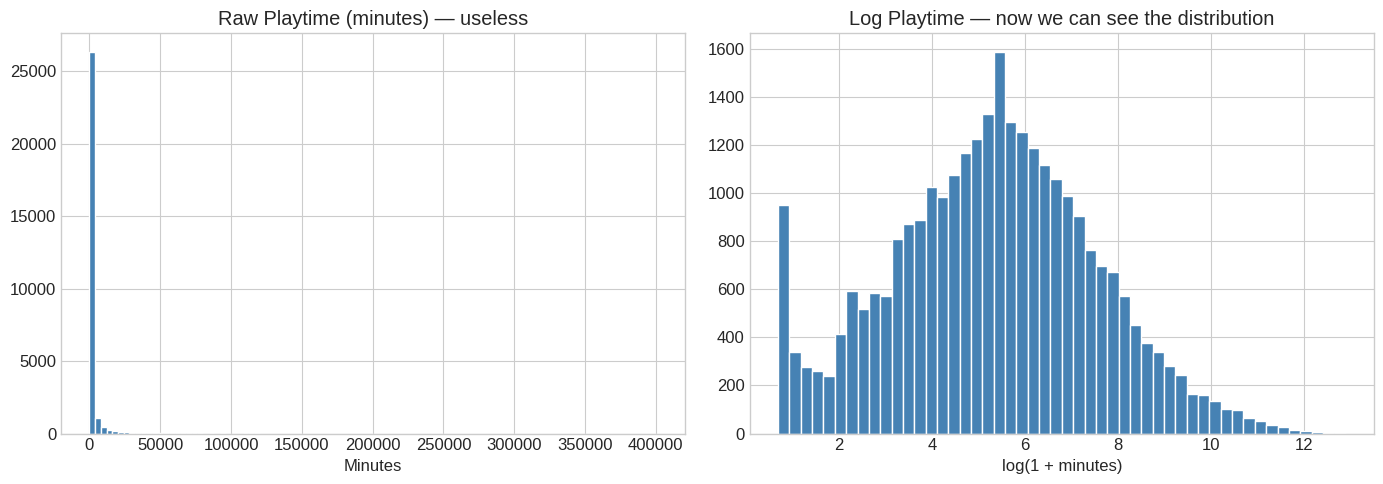


34.1% of interactions have zero playtime (owns game but never played)


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw playtime is unusable as a histogram
nonzero = steam_df[steam_df['playtime_forever'] > 0]['playtime_forever']
axes[0].hist(nonzero, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Playtime (minutes) — useless')
axes[0].set_xlabel('Minutes')

# Log transform makes it interpretable
axes[1].hist(np.log1p(nonzero), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Log Playtime — now we can see the distribution')
axes[1].set_xlabel('log(1 + minutes)')

plt.tight_layout()
plt.show()

zero_pct = (steam_df['playtime_forever'] == 0).mean()
print(f"\n{zero_pct:.1%} of interactions have zero playtime (owns game but never played)")

### Key differences from explicit feedback

1. **No negative signal.** A user not playing a game could mean they don't know it exists, they can't afford it, or they dislike the genre — we can't tell. With explicit ratings, a 1-star rating clearly means "didn't like it."

2. **Noisy magnitude.** 100 hours in a game doesn't mean they like it 10x more than a game with 10 hours. Some genres just take longer (RPGs vs puzzle games). Some games are addictive but frustrating.

3. **Missing values are ambiguous.** In MovieLens, a missing rating is "unknown." In Steam, a missing interaction is "either unknown or disliked" — you can't tell which.

These differences change everything: the loss function (you can't use MSE on implicit data), the training procedure (you need negative sampling), and the evaluation metrics (RMSE is meaningless — you need ranking metrics like Precision@K).

### The cold start problem

New user with zero ratings: their embedding is random noise. New movie with zero ratings: same problem. The model can't recommend anything meaningful.

Solutions:
- **Popularity fallback**: recommend the most popular items until you know more
- **Onboarding**: ask users to rate a few items when they sign up
- **Content-based hybrid**: use item metadata (genre, description) to find similar items even without ratings
- **Transfer learning**: use embeddings from a related domain as initialization

### Feedback loops

Recommended items get more clicks, which makes the model recommend them more. Popular items get more popular. Niche items get buried. Over time, the recommendation system amplifies its own biases rather than discovering new things.

This is a real concern in production systems. Solutions include diversity constraints (force some exploration into recommendations), periodic retraining, and monitoring for representation bias.

The project notebook will give you hands-on practice building a recommendation system with implicit feedback using the Steam dataset. It's a fundamentally different challenge from what we did with MovieLens.

## Part 9: The Bridge to Modern AI

Let's step back and connect everything to what's coming next.

### The embedding story so far

An **embedding** is a learned dense vector representation of a discrete thing. We've now seen this at three scales:

1. **L6 (Tabular MLP)**: Categorical features (job type, education) embedded as small vectors inside a larger model. Embedding dim: 2-6. Vocabulary: 3-12 categories.

2. **This lesson (Collab Filtering)**: Users and movies embedded as the *entire model*. Embedding dim: 32. Vocabulary: 610 users, 9,724 movies.

3. **Coming next (Language Models)**: Words and subwords embedded as input to transformers. Embedding dim: 768-4,096. Vocabulary: 50,000-128,000 tokens.

The concept is identical across all three. The scale is different.

In [41]:
# The progression from L6 → here → language models
progression = pd.DataFrame({
    'Context': ['L6: Job categories', 'L6: Education levels', 'This lesson: MovieLens users', 
                'This lesson: MovieLens movies', 'GPT-2', 'Llama 3'],
    'Code': ['nn.Embedding(12, 6)', 'nn.Embedding(8, 4)', f'nn.Embedding({n_users_idx}, 32)',
             f'nn.Embedding({n_movies_idx}, 32)', 'nn.Embedding(50257, 768)', 'nn.Embedding(128000, 4096)'],
    'Parameters': [12*6, 8*4, n_users_idx*32, n_movies_idx*32, 50257*768, 128000*4096],
    'Trained on': ['Subscription prediction', 'Subscription prediction', 'Rating prediction',
                   'Rating prediction', 'Next token prediction', 'Next token prediction'],
})
progression['Parameters'] = progression['Parameters'].map(lambda x: f'{x:,}')
progression

,Context,Code,Parameters,Trained on
0,L6: Job categories,"nn.Embedding(12, 6)",72,Subscription prediction
1,L6: Education levels,"nn.Embedding(8, 4)",32,Subscription prediction
2,This lesson: MovieLens users,"nn.Embedding(610, 32)","19,520",Rating prediction
3,This lesson: MovieLens movies,"nn.Embedding(9724, 32)","311,168",Rating prediction
4,GPT-2,"nn.Embedding(50257, 768)","38,597,376",Next token prediction
5,Llama 3,"nn.Embedding(128000, 4096)","524,288,000",Next token prediction


### What makes transformers special

After the embedding lookup, transformers use **self-attention**: dot products between all pairs of embedded tokens to figure out which words relate to which. You already know what this dot product means — it's measuring compatibility, just like `user_emb · movie_emb`.

The rest is details (multiple attention heads, layer normalization, feed-forward layers, residual connections), but the foundation is:
1. **Embedding lookup**: discrete token → dense vector (exactly what we did)
2. **Dot product compatibility**: query · key = attention score (exactly what our dot product model computes)
3. **Learned through backpropagation**: adjust embeddings to minimize prediction error (same training loop)

When you encounter attention mechanisms in the LLM lessons, remember: you already built the core operations right here.

## What's Next?

The **project notebook** applies collaborative filtering to the Steam gaming dataset, where you'll work with implicit feedback (playtime instead of star ratings). This is closer to how production recommendation systems actually work — and it's a fundamentally different modeling challenge.

After that, the course moves into **images and CNNs**, then the **modern AI stack** where everything we learned about embeddings becomes the foundation for understanding word embeddings, sentence embeddings, transformers, and RAG systems.

*Updated: 2026_02_22*

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>